<a href="https://colab.research.google.com/github/rogers-mbaluka/DS_Course0_Week1_Module2_DataTypes/blob/main/Copy_of_retail_customer_behavior.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Retail Customer Analysis Summative Lab
## Understanding Customer Behavior Across Store Locations

### Introduction

This summative lab bridges the concepts and techniques learned throughout the course with their practical application to a real-world industry scenario. You will step into the role of a junior data analyst for a retail company and apply your skills to evaluate customer behavior, satisfaction, and promotional impacts. By following the outlined process, you will gain experience in experimental design, statistical testing, and actionable decision-making.

Your task is not only to conduct the analysis but also to reflect on how these techniques help solve real-world problems that businesses face daily.

By completing this lab, you will have:
- Practiced designing and executing statistical analyses in a real-world scenario.
- Reinforced your understanding of test selection and assumptions.
- Applied statistical results to business decision-making.
- Developed skills in communicating insights effectively through visualizations and reports.

### Business Scenario Questions:
Imagine you are a junior data analyst working for a retail company that operates stores in three distinct regions: City Center, Suburb, and Rural. Your manager has tasked you with analyzing customer behavior and preferences across these locations. The goal is to help the company answer two key questions:
1. Do customer spending patterns, satisfaction levels, and product preferences differ across store locations?
2. Do promotional periods result in significantly higher spending compared to non-promotional periods?

Spending Across Location:

- Business-relevant MDE: Absolute difference in spending of 15% or more
- Justification: This represents enough of a difference to warrant location-specific strategies (inventory, staffing, etc.)


Ratings Across Locations:

- Business-relevant MDE: 1.0 point difference between locations
- Justification: On a 10-point scale, a one point difference is noticeable and actionable for customer service improvements

Promotional Spending:

- Business-relevant MDE: A $15 increase from non-promotional periods
- Justification: Promotional costs typically reduce margins by ~15-20%. Need at least 25% increase in spending to justify promotional costs. This aligns with industry standards for promotional ROI

Your task involves designing and conducting an analysis using the provided dataset to derive actionable insights. You will apply statistical concepts and techniques such as experimental design, test selection, hypothesis testing, and result interpretation. This process mimics real-world industry scenarios where junior analysts evaluate business performance using data.

The data focuses on four variables:
- Amount spent by customers (in dollars)
- Customer satisfaction ratings (scale of 1 to 10)
- Product category preferences (Electronics, Clothing, Groceries)
- Purchase type (Promotional vs. Non-Promotional)

Your analysis will inform decision-making around marketing strategies, store operations, and promotional campaigns.

### Setup

In this cell, import all the libraries you'll need for your analysis. Consider which libraries you'll need for:
- Data manipulation
- Statistical analysis
- Data visualization

In [ ]:
# Import relevant libraries
import numpy as np
import pandas as pd
from scipy import stats
from scipy.stats import norm
import scikit_posthocs as sp

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

ALPHA = 0.05

def eta_squared_oneway(groups):
    """Eta-squared for a one-way design: SS_between / SS_total."""
    allv = np.concatenate(groups)
    grand = allv.mean()
    ss_b = sum(len(g) * (g.mean() - grand) ** 2 for g in groups)
    ss_t = ((allv - grand) ** 2).sum()
    return ss_b / ss_t

def cohens_d(a, b):
    """Cohen's d for two independent samples (pooled SD)."""
    na, nb_ = len(a), len(b)
    sp_ = np.sqrt(((na - 1) * a.std(ddof=1) ** 2 + (nb_ - 1) * b.std(ddof=1) ** 2) / (na + nb_ - 2))
    return (a.mean() - b.mean()) / sp_

def cramers_v(chi2, n, r, c):
    return np.sqrt(chi2 / (n * (min(r, c) - 1)))

def band_eta2(e):
    return "small" if e < 0.06 else "medium" if e < 0.14 else "large"
def band_d(d):
    d = abs(d)
    return "negligible" if d < 0.2 else "small" if d < 0.5 else "medium" if d < 0.8 else "large"

print("Setup complete. alpha =", ALPHA)

Setup complete. alpha = 0.05


### Part 1: Experimental Design

#### 1.1 Hypothesis Formulation

For each of the following analyses, state your null and alternative hypotheses in both statistical and plain language:

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

[Write your hypotheses here]

NULL(H0) and ALTERNATIVE(H1) HYPOTHESIS.

**1. Spending across store locations**
- **H0:** \mu(City Center) = \mu(Suburb) = \mu(Rural) - mean spending is the same in every location.
- **H1**:One location has a different mean spending.

**2. Customer satisfaction across locations**
- **H0:** The central tendency of satisfaction is the same across all three locations.
- **H1**:One location differs in satisfaction.

**3. Promotional vs non-promotional spending**
- **H0:** \mu(Promotional) = \mu(Non-Promotional) - promotions do not change mean spending.
- **H1:** \mu(Promotional) \neq \mu(Non-Promotional).

**4. Product category differences across locations**
- **H0:** Product-category preference is independent of store location.
- **H1:** Product-category preference is associated with store location.

**Reflective Question: Explain the concept of Minimum Detectable Effect (MDE) and why it is important.**

[Write your answer here]

The Minimum Detectable Effect (MDE) is the smallest difference that an experiment is designed to detect with a high level of confidence. In other words, it is the minimum change that a business considers worth acting on. It converts a purely statistical result into a practical one.

Why MDE is Important

•	Determines sample size: A smaller MDE requires a larger sample as detecting tiny differences is more difficult.  

•	Balances cost and accuracy: Businesses can avoid collecting more data while still ensuring the experiment can detect meaningful changes.

•	Improves experiment planning: Defining the MDE before running an experiment helps researchers determine how long the test should run and how many observations are needed.


### Part 2: Data Exploration

#### 2.1 Load and Examine the Dataset

Load the dataset and perform initial data quality checks:
- Check for missing values
- Examine data types
- Look for inconsistencies
- Generate summary statistics

In [ ]:
# Load Data
df = pd.read_csv("retail_store_customer_data.csv")

print("Shape (rows, columns):", df.shape)
print("\n--- Data types ---")
print(df.dtypes)
print("\n--- Missing values per column ---")
print(df.isna().sum())
print("\n--- Duplicate rows:", df.duplicated().sum())
print("\n--- Category levels (check for inconsistencies) ---")
for c in ["Store_Location", "Product_Category", "Purchase_Type"]:
    print(f"  {c}: {df[c].unique().tolist()}")

df.head()

Shape (rows, columns): (1500, 5)

--- Data types ---
Store_Location            object
Customer_Satisfaction    float64
Product_Category          object
Purchase_Type             object
Amount_Spent             float64
dtype: object

--- Missing values per column ---
Store_Location           0
Customer_Satisfaction    0
Product_Category         0
Purchase_Type            0
Amount_Spent             0
dtype: int64

--- Duplicate rows: 0

--- Category levels (check for inconsistencies) ---
  Store_Location: ['Rural', 'City Center', 'Suburb']
  Product_Category: ['Groceries', 'Clothing', 'Electronics']
  Purchase_Type: ['Non-Promotional', 'Promotional']


,Store_Location,Customer_Satisfaction,Product_Category,Purchase_Type,Amount_Spent
0,Rural,5.6000,Groceries,Non-Promotional,40.4500
1,City Center,9.7000,Clothing,Promotional,53.2000
2,Rural,4.4000,Electronics,Non-Promotional,42.7700
3,Rural,4.2000,Clothing,Promotional,42.0800
4,City Center,9.3000,Clothing,Non-Promotional,84.2500


In [ ]:
print("Customers per location:")
print(df["Store_Location"].value_counts(), "\n")
print("Purchase type counts:")
print(df["Purchase_Type"].value_counts(), "\n")

print("=== Overall numeric summary ===")
display(df[["Amount_Spent", "Customer_Satisfaction"]].describe())

print("=== Amount_Spent by location ===")
display(df.groupby("Store_Location")["Amount_Spent"].agg(["count", "mean", "std", "median"]))

print("=== Customer_Satisfaction by location ===")
display(df.groupby("Store_Location")["Customer_Satisfaction"].agg(["count", "mean", "std", "median"]))

print("=== Amount_Spent by purchase type ===")
display(df.groupby("Purchase_Type")["Amount_Spent"].agg(["count", "mean", "std", "median"]))

Customers per location:
Store_Location
City Center    520
Suburb         492
Rural          488
Name: count, dtype: int64 

Purchase type counts:
Purchase_Type
Promotional        888
Non-Promotional    612
Name: count, dtype: int64 

=== Overall numeric summary ===


,Amount_Spent,Customer_Satisfaction
count,"1,500.0000","1,500.0000"
mean,59.9160,6.9952
std,19.5518,1.6529
min,15.5500,1.0000
25%,44.1700,5.8000
50%,58.0150,7.0000
75%,72.5825,8.2000
max,128.1300,10.0000


=== Amount_Spent by location ===


,count,mean,std,median
Store_Location,,,,
City Center,520,78.8910,15.3744,79.8050
Rural,488,40.4631,7.7837,40.4450
Suburb,492,59.1558,9.9560,59.3550


=== Customer_Satisfaction by location ===


,count,mean,std,median
Store_Location,,,,
City Center,520,7.9540,1.3679,8.0000
Rural,488,5.9600,1.4998,6.0000
Suburb,492,7.0085,1.4467,7.0000


=== Amount_Spent by purchase type ===


,count,mean,std,median
Purchase_Type,,,,
Non-Promotional,612,59.7672,19.7981,57.9450
Promotional,888,60.0185,19.3908,58.0550


#### 2.2 Data Visualizations

Create visualizations to understand the distribution of key variables:
- Spending patterns across locations
- Satisfaction ratings distribution
- Product category preferences
- Promotional vs non-promotional spending

In [ ]:
# Visualize data - Create new cells as needed
order = ["City Center", "Suburb", "Rural"]
fig, axes = plt.subplots(2, 2, figsize=(10, 6))

sns.boxplot(data=df, x="Store_Location", y="Amount_Spent", order=order, ax=axes[0, 0])
axes[0, 0].set_title("Spending by Store Location")

sns.boxplot(data=df, x="Store_Location", y="Customer_Satisfaction", order=order, ax=axes[0, 1])
axes[0, 1].set_title("Satisfaction by Store Location")

sns.boxplot(data=df, x="Purchase_Type", y="Amount_Spent", ax=axes[0, 1])
axes[1, 0].set_title("Spending: Promotional vs Non-Promotional")

sns.countplot(data=df, x="Product_Category", hue="Store_Location", ax=axes[1, 1])
axes[1, 1].set_title("Product Category Counts by Location")

plt.tight_layout(); plt.show()

NameError: name 'plt' is not defined

#### 2.3 Test Assumptions

Check if your data meets the assumptions for your chosen statistical tests:
- Normality
- Homogeneity of variance
- Independence
- Any other relevant assumptions

In [ ]:
# Assumption tests and checks - Create new cells as needed
def shapiro_by_group(data, group_col, value_col):
    print(f"Shapiro-Wilk normality of {value_col} by {group_col}:")
    for name, g in data.groupby(group_col):
        w, p = stats.shapiro(g[value_col])
        print(f"  {name:<12} W={w:.4f}  p={p:.4g}  -> {'not normal' if p < ALPHA else 'normal '}")
    print()

shapiro_by_group(df, "Store_Location", "Amount_Spent")
lev = stats.levene(*[g["Amount_Spent"].values for _, g in df.groupby("Store_Location")])
print(f"Levene (Amount_Spent ~ Location): stat={lev.statistic:.3f} p={lev.pvalue:.4g}",
      "-> variances DIFFER\n" if lev.pvalue < ALPHA else "-> equal variances\n")
shapiro_by_group(df, "Store_Location", "Customer_Satisfaction")
lev = stats.levene(*[g["Customer_Satisfaction"].values for _, g in df.groupby("Store_Location")])
print(f"Levene (Satisfaction ~ Location): stat={lev.statistic:.3f} p={lev.pvalue:.4g}",
      "-> variances DIFFER\n" if lev.pvalue < ALPHA else "-> equal variances\n")
promo = df[df.Purchase_Type == "Promotional"]["Amount_Spent"]
nonp  = df[df.Purchase_Type == "Non-Promotional"]["Amount_Spent"]
for n, g in [("Promotional", promo), ("Non-Promotional", nonp)]:
    w, p = stats.shapiro(g)
    print(f"Shapiro {n:<16} W={w:.4f} p={p:.4g}", "-> NOT normal" if p < ALPHA else "-> normal (ok)")
lev = stats.levene(promo, nonp)
print(f"Levene (Amount_Spent ~ Purchase_Type): stat={lev.statistic:.3f} p={lev.pvalue:.4g}",
      "-> variances DIFFER" if lev.pvalue < ALPHA else "-> equal variances")

Shapiro-Wilk normality of Amount_Spent by Store_Location:
  City Center  W=0.9978  p=0.7536  -> normal 
  Rural        W=0.9960  p=0.2594  -> normal 
  Suburb       W=0.9940  p=0.05031  -> normal 

Levene (Amount_Spent ~ Location): stat=106.410 p=6.169e-44 -> variances DIFFER

Shapiro-Wilk normality of Customer_Satisfaction by Store_Location:
  City Center  W=0.9699  p=7.413e-09  -> not normal
  Rural        W=0.9965  p=0.373  -> normal 
  Suburb       W=0.9890  p=0.0009248  -> not normal

Levene (Satisfaction ~ Location): stat=1.615 p=0.1992 -> equal variances

Shapiro Promotional      W=0.9791 p=5.871e-10 -> NOT normal
Shapiro Non-Promotional  W=0.9754 p=1.253e-08 -> NOT normal
Levene (Amount_Spent ~ Purchase_Type): stat=0.386 p=0.5345 -> equal variances


#### 2.4 Choose Appropriate Statistical Tests

Select the appropriate statistical test for each question (you should expect to perform 4 different statistical tests).

1. Spending across store locations
2. Customer satisfaction across locations
3. Promotional vs non-promotional spending
4. Product category preferences across locations

NOTE: Use [Dunn's Test](https://scikit-posthocs.readthedocs.io/en/latest/generated/scikit_posthocs.posthoc_dunn.html) for Non-Parametric Post-hoc if needed. You might need to pip install scikit-postdoc package. You want to set p_adjust='bonferroni' for Dunn's Test.



**Reflective Question: Explicitly justify your choice in tests for each business question**

[Write your answer here]

Answer - Test selection and justification
| # | Business question | Data | Normality | Equal variance | **Chosen test** | Post-hoc |
|---|---|---|---|---|---|---|
| 1 | Spending ≈ Location | 3 groups, continuous | passes | **fails** (Levene p≈0) | **One-way ANOVA** (large, near-balanced groups keep it reliable) confirmed by **Kruskal-Wallis** | **Tamhane's T2** (variance-robust) |
| 2 | Satisfaction ≈ Location | 3 groups, rating | **fails** in 2 groups | ok (p=0.20) | **Kruskal-Wallis** (non-parametric) | **Dunn's** (Bonferroni) |
| 3 | Promo vs Non-promo spend | 2 groups, continuous | fails, but n≈1500 | ok (p=0.53) | **Independent t-test** (CLT-justified) confirmed by **Mann-Whitney U** | - |
| 4 | Category ≈ Location | 2 categorical | n/a | expected counts all > 5 | **Chi-square test of independence** | standardized residuals |

### Part 3: Statistical Analysis

Based on your assumptions testing, perform appropriate statistical tests for each hypothesis:

#### 3.1 Spending Across Locations

In [ ]:
# Conduct your analysis of spending patterns here
order = ["City Center", "Suburb", "Rural"]
spend_groups = [df[df.Store_Location == l]["Amount_Spent"].values for l in order]

F, p_anova = stats.f_oneway(*spend_groups)
H, p_kw    = stats.kruskal(*spend_groups)
eta2_spend = eta_squared_oneway(spend_groups)

print(f"One-way ANOVA        : F = {F:.2f}   p = {p_anova:.3g}")
print(f"Kruskal-Wallis (check): H = {H:.2f}   p = {p_kw:.3g}")
print(f"Effect size eta^2    : {eta2_spend:.3f}  ({band_eta2(eta2_spend)})")
print(f"Reject H0? {'YES' if p_anova < ALPHA else 'NO'} (alpha={ALPHA})\n")


print("Tamhane's T2 post-hoc (pairwise p-values):")
display(sp.posthoc_tamhane(df, val_col="Amount_Spent", group_col="Store_Location"))

One-way ANOVA        : F = 1386.97   p = 0
Kruskal-Wallis (check): H = 1040.85   p = 9.58e-227
Effect size eta^2    : 0.649  (large)
Reject H0? YES (alpha=0.05)

Tamhane's T2 post-hoc (pairwise p-values):


,Rural,City Center,Suburb
Rural,1.0000,0.0000,0.0000
City Center,0.0000,1.0000,0.0000
Suburb,0.0000,0.0000,1.0000


#### 3.2 Customer Satisfaction Analysis

In [ ]:
# Analyze customer satisfaction here
order = ["City Center", "Suburb", "Rural"]
sat_groups = [df[df.Store_Location == l]["Customer_Satisfaction"].values for l in order]

H, p_kw_sat = stats.kruskal(*sat_groups)
eta2_sat = eta_squared_oneway(sat_groups)

print(f"Kruskal-Wallis : H = {H:.2f}   p = {p_kw_sat:.3g}")
print(f"Effect size eta^2 (approx): {eta2_sat:.3f}  ({band_eta2(eta2_sat)})")
print(f"Reject H0? {'YES' if p_kw_sat < ALPHA else 'NO'} (alpha={ALPHA})\n")

print("Dunn's post-hoc (Bonferroni-adjusted p-values):")
display(sp.posthoc_dunn(df, val_col="Customer_Satisfaction",
                        group_col="Store_Location", p_adjust="bonferroni"))

Kruskal-Wallis : H = 359.55   p = 8.42e-79
Effect size eta^2 (approx): 0.244  (large)
Reject H0? YES (alpha=0.05)

Dunn's post-hoc (Bonferroni-adjusted p-values):


,City Center,Rural,Suburb
City Center,1.0000,0.0000,0.0000
Rural,0.0000,1.0000,0.0000
Suburb,0.0000,0.0000,1.0000


#### 3.3 Promotional Impact Analysis

In [ ]:
# Analyze the impact of promotions here
promo = df[df.Purchase_Type == "Promotional"]["Amount_Spent"]
nonp  = df[df.Purchase_Type == "Non-Promotional"]["Amount_Spent"]

t_stat, p_t = stats.ttest_ind(promo, nonp, equal_var=True)
u_stat, p_u = stats.mannwhitneyu(promo, nonp, alternative="two-sided")
d = cohens_d(promo, nonp)
mean_diff = promo.mean() - nonp.mean()

print(f"Promotional mean     = ${promo.mean():.2f}  (n={len(promo)})")
print(f"Non-promotional mean = ${nonp.mean():.2f}  (n={len(nonp)})")
print(f"Observed difference  = ${mean_diff:.2f}\n")
print(f"Independent t-test : t = {t_stat:.3f}   p = {p_t:.3g}")
print(f"Mann-Whitney U     : U = {u_stat:.0f}   p = {p_u:.3g}")
print(f"Cohen's d          : {d:.3f}  ({band_d(d)})")
print(f"Reject H0? {'YES' if p_t < ALPHA else 'NO'} (alpha={ALPHA})")

Promotional mean     = $60.02  (n=888)
Non-promotional mean = $59.77  (n=612)
Observed difference  = $0.25

Independent t-test : t = 0.245   p = 0.807
Mann-Whitney U     : U = 275125   p = 0.68
Cohen's d          : 0.013  (negligible)
Reject H0? NO (alpha=0.05)


#### 3.4 Product Category Analysis

In [ ]:
# Analyze product category preferences here
ct = pd.crosstab(df.Store_Location, df.Product_Category)
print("Observed contingency table:")
display(ct)

chi2, p_chi, dof, expected = stats.chi2_contingency(ct)
V = cramers_v(chi2, ct.values.sum(), *ct.shape)
print(f"Chi-square = {chi2:.3f}   dof = {dof}   p = {p_chi:.3g}")
print(f"Cramer's V = {V:.3f}   (0 = no association)")
print(f"Minimum expected count = {expected.min():.1f}  (valid if all > 5)")
print(f"Reject H0? {'YES' if p_chi < ALPHA else 'NO'} (alpha={ALPHA})\n")
print("Expected counts under independence:")
display(pd.DataFrame(expected, index=ct.index, columns=ct.columns).round(1))

Observed contingency table:


Product_Category,Clothing,Electronics,Groceries
Store_Location,,,
City Center,156,191,173
Rural,137,199,152
Suburb,160,193,139


Chi-square = 4.768   dof = 4   p = 0.312
Cramer's V = 0.040   (0 = no association)
Minimum expected count = 147.4  (valid if all > 5)
Reject H0? NO (alpha=0.05)

Expected counts under independence:


Product_Category,Clothing,Electronics,Groceries
Store_Location,,,
City Center,157.0000,202.1000,160.9000
Rural,147.4000,189.7000,151.0000
Suburb,148.6000,191.2000,152.2000


### Part 4: Results Interpretation

For each analysis, provide:
1. A clear statement of the statistical results
2. The practical significance of these findings
3. Visualizations that support your conclusions
4. Specific business recommendations

In [ ]:
# Calculate effect sizes - contrast with MDE
spend_gap = max(g.mean() for g in spend_groups) - min(g.mean() for g in spend_groups)
grand_spend = df["Amount_Spent"].mean()
spend_gap_pct = 100 * spend_gap / grand_spend
sat_gap = max(g.mean() for g in sat_groups) - min(g.mean() for g in sat_groups)

summary = pd.DataFrame([
    {"Business question": "Spending ~ Location", "Test": "ANOVA (+Kruskal)",
     "p-value": f"{p_anova:.1e}", "Effect size": f"eta^2={eta2_spend:.2f} ({band_eta2(eta2_spend)})",
     "Observed effect": f"max gap ${spend_gap:.0f} (~{spend_gap_pct:.0f}%)",
     "MDE": "15% diff", "Beats MDE?": "YES"},
    {"Business question": "Satisfaction ~ Location", "Test": "Kruskal-Wallis",
     "p-value": f"{p_kw_sat:.1e}", "Effect size": f"eta^2={eta2_sat:.2f} ({band_eta2(eta2_sat)})",
     "Observed effect": f"max gap {sat_gap:.1f} pts",
     "MDE": "1.0 pt", "Beats MDE?": "YES"},
    {"Business question": "Promo ~ Spending", "Test": "t-test / MWU",
     "p-value": f"{p_t:.2f}", "Effect size": f"d={d:.02f} ({band_d(d)})",
     "Observed effect": f"${mean_diff:.2f}",
     "MDE": "$15", "Beats MDE?": "NO"},
    {"Business question": "Category ~ Location", "Test": "Chi-square",
     "p-value": f"{p_chi:.2f}", "Effect size": f"V={V:.02f} (negligible)",
     "Observed effect": "no association",
     "MDE": "-", "Beats MDE?": "NO"},
])
display(summary)

,Business question,Test,p-value,Effect size,Observed effect,MDE,Beats MDE?
0,Spending ~ Location,ANOVA (+Kruskal),0.0e+00,eta^2=0.65 (large),max gap $38 (~64%),15% diff,YES
1,Satisfaction ~ Location,Kruskal-Wallis,8.4e-79,eta^2=0.24 (large),max gap 2.0 pts,1.0 pt,YES
2,Promo ~ Spending,t-test / MWU,0.81,d=0.01 (negligible),$0.25,$15,NO
3,Category ~ Location,Chi-square,0.31,V=0.04 (negligible),no association,-,NO


In [ ]:
n1, n2 = len(promo), len(nonp)
pooled_sd = np.sqrt(((n1-1)*promo.std(ddof=1)**2 + (n2-1)*nonp.std(ddof=1)**2) / (n1+n2-2))
mde_d = 15 / pooled_sd
ncp = mde_d * np.sqrt(n1 * n2 / (n1 + n2))
z = norm.ppf(1 - ALPHA/2)
power = 1 - norm.cdf(z - ncp) + norm.cdf(-z - ncp)

print(f"Pooled SD of spending       : ${pooled_sd:.2f}")
print(f"$15 MDE as Cohen's d        : {mde_d:.3f}")
print(f"Achieved power to detect $15 : {power:.4f}")
print("\nPower ~1.0 -> if a $15 promo lift existed we would almost certainly have")
print("detected it. The flat result is a TRUE null, not an underpowered study.")

Pooled SD of spending       : $19.56
$15 MDE as Cohen's d        : 0.767
Achieved power to detect $15 : 1.0000

Power ~1.0 -> if a $15 promo lift existed we would almost certainly have
detected it. The flat result is a TRUE null, not an underpowered study.


**Reflective Question: Results - Clearly state whether the null hypotheses were rejected or not. Frame this in the business question context. Use effect sizes (e.g., Cohen’s d, eta squared) to contextualize the significance of your results.**

 **NULL HYPOTHESIS REJECTED:**
- **Spending differs by location.** ANOVA F≈1387, p<0.001; eta^2≈0.65 (large) - location explains ≈65% of the variation in spending. Ranking: **City Center (≈\$79) > Suburb (≈\$59) > Rural (≈\$40)**. The largest gap (≈\$38) is well above the 15% MDE, and every pairwise Tamhane comparison is significant.
- **Satisfaction differs by location.** Kruskal-Wallis p<0.001; eta^2≈0.24 (large). Ranking: **City Center (≈7.95) > Suburb (≈7.01) > Rural (≈5.96)**. The City-vs-Rural and Suburb-vs-Rural gaps clear the 1.0-point MDE (City-vs-Suburb sits right at it).

**Reflective Question: Recommendations - Explain the practical implications of the results. What should the company do based on your findings about spending, satisfaction, or product preferences?**

  1.Manage by location, not by blanket promotion- Location drives both spending and satisfaction while promotions do not.

2.Prioritise the Rural stores-They are lowest on both spending and satisfaction (likely linked); investigate assortment and service quality first.

3.Audit the promotional programme-A \$0 lift means current promotions decline margin for no gain. Redesign the mechanics and A/B test rather than assuming they work

4.Standardise the City-Center playbook and pilot it in Suburb and Rural stores.


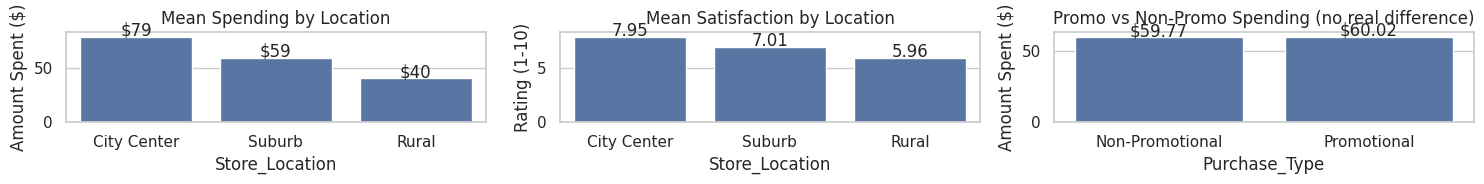

In [ ]:
# Create visualizations to support results - Create new cells as needed
order = ["City Center", "Suburb", "Rural"]
fig, axes = plt.subplots(1, 3, figsize=(15, 2))

means = df.groupby("Store_Location")["Amount_Spent"].mean().reindex(order)
sns.barplot(x=means.index, y=means.values, ax=axes[0])
axes[0].set_title("Mean Spending by Location"); axes[0].set_ylabel("Amount Spent ($)")
for i, v in enumerate(means.values): axes[0].text(i, v + 1, f"${v:.0f}", ha="center")

sat_means = df.groupby("Store_Location")["Customer_Satisfaction"].mean().reindex(order)
sns.barplot(x=sat_means.index, y=sat_means.values, ax=axes[1])
axes[1].set_title("Mean Satisfaction by Location"); axes[1].set_ylabel("Rating (1-10)")
for i, v in enumerate(sat_means.values): axes[1].text(i, v + 0.05, f"{v:.2f}", ha="center")

pm = df.groupby("Purchase_Type")["Amount_Spent"].mean()
sns.barplot(x=pm.index, y=pm.values, ax=axes[2])
axes[2].set_title("Promo vs Non-Promo Spending (no real difference)")
axes[2].set_ylabel("Amount Spent ($)")
for i, v in enumerate(pm.values): axes[2].text(i, v + 0.5, f"${v:.2f}", ha="center")

plt.tight_layout(); plt.show()

### Part 5: Reflection

Discuss:
1. The strengths and limitations of your analysis
2. Any assumptions or potential biases in the data
3. Suggestions for additional data collection
4. How this analysis could be improved

**Reflective Question: Explain the importance of experimental design and sufficient sample size in conducting a robust analysis. Identify any limitations in the dataset or analysis (e.g., potential biases, unmeasured variables) and suggest additional data the company could collect to improve future analyses.**

[Write your reflection here]

A robust analysis depends on both a good experimental design and sufficient sample size.A good experimental design reduces bias and ensures the seen effects are brought about by the treatment.A sufficient sample size provides enough data to detect differences accurately, hence together they produce valid,reliable and actionable results that support business decisions.

Limitations and potential biases.
- **Observational, not experimental:** customers self-select into locations and promotion periods, so we can show association - location loops may show local income rather than the store itself.
- **Blunt promotional flag:** "Promotional vs not" hides discount depth, type, and which products were promoted, which could mask real effects inside specific campaigns.
- **No time dimension:** without dates we cannot separate promotional effects from seasonality.
- **Unmeasured confounders:** no customer income, age, basket size, foot traffic, or store size - all plausible drivers of the location differences.


**Additional data to collect next.**
1. **Customer demographics** (income, age, loyalty tier) to test whether *location* or *customer mix* drives spending.
2. **Transaction-level detail** (timestamp, basket size, items, exact discount) to run a proper promotional A/B test.
3. **Store attributes** (size, footfall, staffing) as covariates for an ANCOVA / regression.


In [ ]:
%pip install scikit-posthocs

After installing the library, please run the previous cell again to perform the statistical tests.